# Model Hassella

X_{t+1} = lambda * X_{t} * (1 + X_{t})^beta

Pytanie badawcze - o co nam chodzi? jaka jest zakładana przestrzeń parametrów?

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def calculate_next_hassell(xt, l, b):
    return l * xt * (1 + xt)**(-b)

def calculate_iterations(xt, l, b, iterations = 3000, returned_ters = 1000):
    iters = [xt]
    for i in range(iterations):
        iters.append(calculate_next_hassell(iters[-1], l, b))
    
    return iters[-returned_ters:]

def check_type(iters):
    slownik_wystapien = {}
    for val in iters[-200:]:  # Sprawdzamy tylko ostatnie 200 iteracji
        rounded_val = round(val, 4)
        
        if rounded_val in slownik_wystapien:
            slownik_wystapien[rounded_val] += 1
        else:
            slownik_wystapien[rounded_val] = 1
    
    point_type = None
    unikalne_wartosci = len(slownik_wystapien)
    
    if unikalne_wartosci == 1:
        point_type = 'stable'
    elif unikalne_wartosci == 2:
        point_type = '2cycle'
    elif unikalne_wartosci == 3:
        point_type = '3cycle'
    elif unikalne_wartosci == 4:
        point_type = '4cycle'
    elif ( unikalne_wartosci > 4 and unikalne_wartosci <= 8):
        point_type = '5to8cycle'
    elif ( unikalne_wartosci > 8 and unikalne_wartosci <= 16):
        point_type = '8_to_16cycle'
    elif unikalne_wartosci > 16:
        point_type = 'chaotic'

    return point_type

def plot_trajectory(xt, l, b):
    iters = calculate_iterations(xt, l, b)
    plt.plot(iters)
    plt.title(f'Trajectory for lambda={l} and beta={b}')
    plt.xlabel('Iteration')
    plt.ylabel('Population Size')
    plt.show()

def plot_bifurcation(lambda_vals, beta_vals, x_0):
    Z = np.zeros((len(beta_vals), len(lambda_vals)))
    
    color_map = {
        'stable': 0,
        '2cycle': 1,
        '3cycle': 2,
        '4cycle': 3,
        '5to8cycle': 4,
        '8_to_16cycle': 5,
        'chaotic': 6
    }
    
    print("Trwa obliczanie mapy bifurkacji... Proszę czekać.")
    for i, b in enumerate(beta_vals):
        for j, l in enumerate(lambda_vals):
            iters = calculate_iterations(x_0, l, b)
            point_type = check_type(iters)
            
            Z[i, j] = color_map[point_type]
            
    plt.figure(figsize=(12, 8))
    
    mesh = plt.pcolormesh(lambda_vals, beta_vals, Z, cmap='turbo', shading='auto')
    
    cbar = plt.colorbar(mesh, ticks=[0, 1, 2, 3, 4, 5, 6])
    cbar.ax.set_yticklabels(['Stable', '2-cycle', '3-cycle', '4-cycle', '5-8 cycle', '8-16 cycle', 'Chaotic'])
    
    plt.title('Bifurcation Diagram - Model Hassella', fontsize=16)
    plt.xlabel('Lambda (\u03BB)', fontsize=14)
    plt.ylabel('Beta (\u03B2)', fontsize=14)
    plt.show()

In [2]:
x_0 = 1
lambda_vals = np.linspace(0,1000, 500)
beta_vals = np.linspace(0,10, 200)

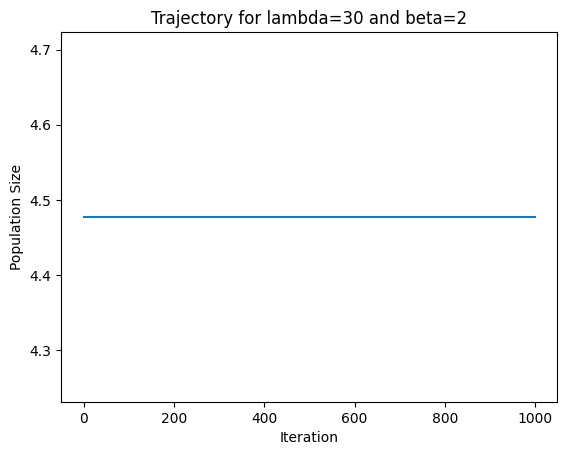

In [3]:
plot_trajectory(x_0, 30, 2)

In [ ]:
plot_bifurcation(lambda_vals, beta_vals, x_0)

Trwa obliczanie mapy bifurkacji... Proszę czekać.


/tmp/ipykernel_24699/186697421.py:8: RuntimeWarning: overflow encountered in scalar multiply
  return l * xt * (1 + xt)**(-b)


In [ ]:
import streamlit as st